## Run CITE-pool (Integration and Clustering)

In [5]:
import scanpy as sc 
import pandas as pd
import RunCITEpool
import numpy as np

In [7]:
data_path = ['../data/mosaic celltype/data3.h5ad']
output_path = '../output/mosaic celltype/3tem_test++/'
cutoff = 0.45
current_treepath = '../output/mosaic celltype/3tem_test++/'
FinetuneNonde = [5]
ifretrain = False


RunCITEpool.main(data_path, output_path, cutoff, 
                current_treepath, FinetuneNonde, ifretrain)


## Results Visualization

### Loading Data

#### Option 1: Load datasets under different folders in data_path

In [52]:
## Load and concat RNA data
inbatch, adtdata, rnadata = [1], {}, {}
for i in range(len(data_path)):
    data = sc.read_h5ad(data_path[i])
    batch = data.obs['batch'].cat.categories
    # adtdata[i] = data[:,data.var['feature_types']=='Antibody Capture']     
    rnadata[i] = data[:,data.var['feature_types']=='Gene Expression']
    rnadata[i].obs['pred'] = None


    for j in range(len(batch)):
        file = str(i+1)+'/'+str(j+inbatch[-1])
        leaflabel = pd.read_csv(output_path+file+'/leaf_labels.csv',index_col=0)
        treelabel = pd.read_csv(output_path+file+'/treelabel.csv',index_col=0)
        embedding = pd.read_csv(output_path+file+'/embedding.csv',index_col=0)
        indices = rnadata[i].obs_names.isin(leaflabel.index)
        rnadata[i].obs['pred'][indices] = leaflabel['Label']
        
        if j == 0:
            rnadata[i].obsm['treelabel'] = np.zeros((rnadata[i].shape[0],embedding.shape[1]))
            rnadata[i].obsm['embedding'] = np.zeros((rnadata[i].shape[0],embedding.shape[1]))
        rnadata[i].obsm['treelabel'][indices] = treelabel.values
        rnadata[i].obsm['embedding'][indices] = embedding.values


    inbatch.append(j+1)

adata = sc.concat(rnadata.values(), axis=0, join='inner')

adata.write_h5ad(output_path+'reuslt.h5ad')

#### Option 2: If datasets concatenated, directly load results

### Integrated data umap visualization with embedding

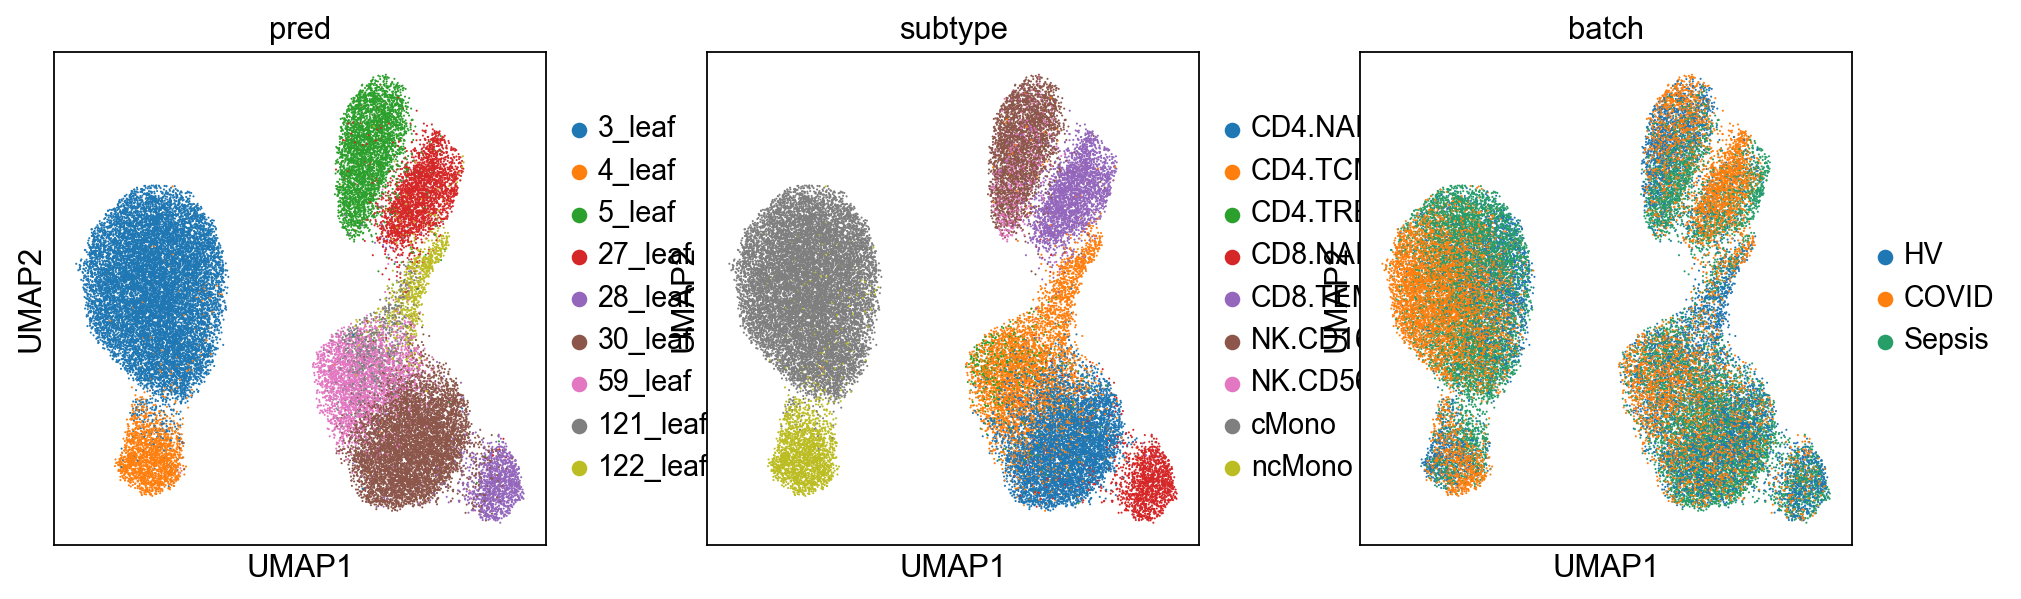

In [56]:
sc.set_figure_params(facecolor='white')
sc.pp.neighbors(adata, n_neighbors=20, use_rep='embedding', key_added='embedding')
sc.tl.umap(adata, neighbors_key='embedding')
sc.pl.umap(adata, color=['pred','subtype','batch'])

### Visualization of each embedding

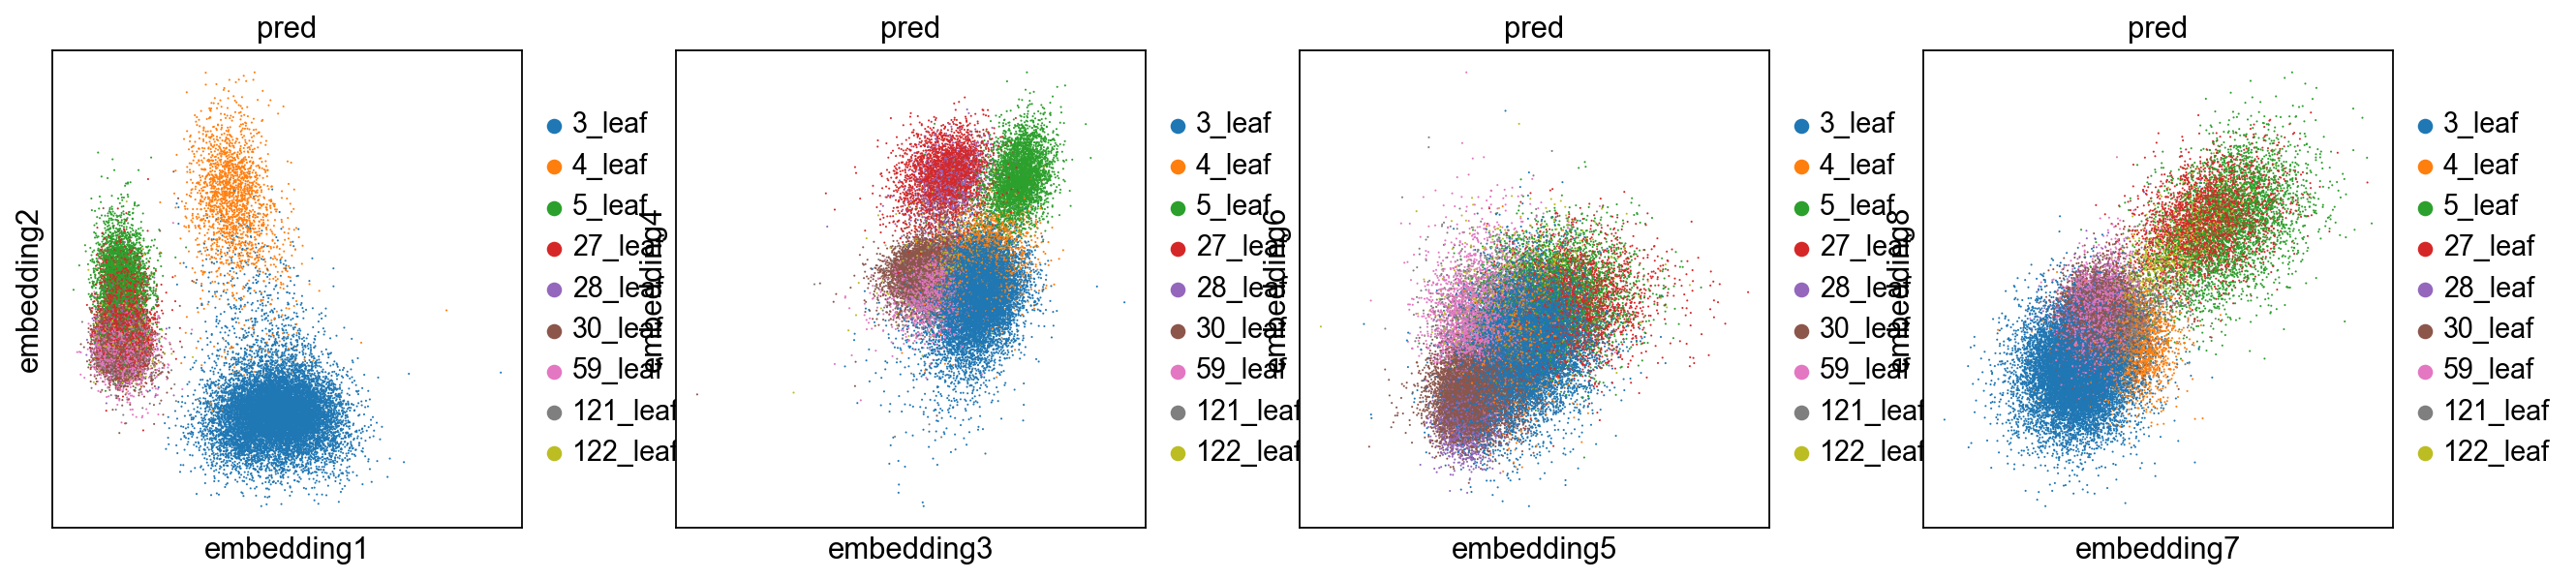

In [57]:
sc.pl.embedding(adata, basis='embedding', components=['1,2','3,4','5,6','7,8'],color=['pred'])

## Advanced Analysis

### Bimodal property of Pseudo-marker at each node layer

In [59]:
tree_label

,0,1,2,6,13,14,29,60
AAACCTGTCAGGATCT-1-gPlexA1_s1,4.578556,-0.739358,1.129823,-1.461428,2.246070,1.321244,-0.996914,-0.770888
AAACGGGTCATTTGGG-1-gPlexA1_s1,-0.479294,0.648850,0.449878,-0.100436,1.108157,-0.046128,0.335540,-0.002659
AAAGATGAGGTCATCT-1-gPlexA1_s1,4.424108,-0.478929,0.762617,-0.828863,1.606380,1.414090,-1.038089,-0.485496
AAAGATGTCTTAGCCC-1-gPlexA1_s1,4.920449,-0.400788,1.289020,-1.066261,2.065707,1.261200,-1.446719,-0.796292
AAAGCAAGTATCGCAT-1-gPlexA1_s1,0.035422,0.995545,0.283099,0.993623,0.704546,0.330370,-0.158741,-0.193597
...,...,...,...,...,...,...,...,...
TTGTAGGCATCACGTA-1-gPlexJ7_s1,6.047442,-0.196708,1.313817,-1.135858,1.251451,2.173596,-0.987275,-0.005501
TTTACTGAGACACTAA-1-gPlexJ7_s1,-0.041515,0.702919,0.919408,1.420311,2.865110,1.424182,1.790508,2.113710
TTTGCGCCAATGAAAC-1-gPlexJ7_s1,5.050991,-0.033747,0.419665,-0.524415,1.971299,1.861129,-0.056169,-1.856956
TTTGCGCGTACCGCTG-1-gPlexJ7_s1,5.886582,-0.312583,1.247594,-0.314827,1.676596,1.836693,-1.232155,-1.968898


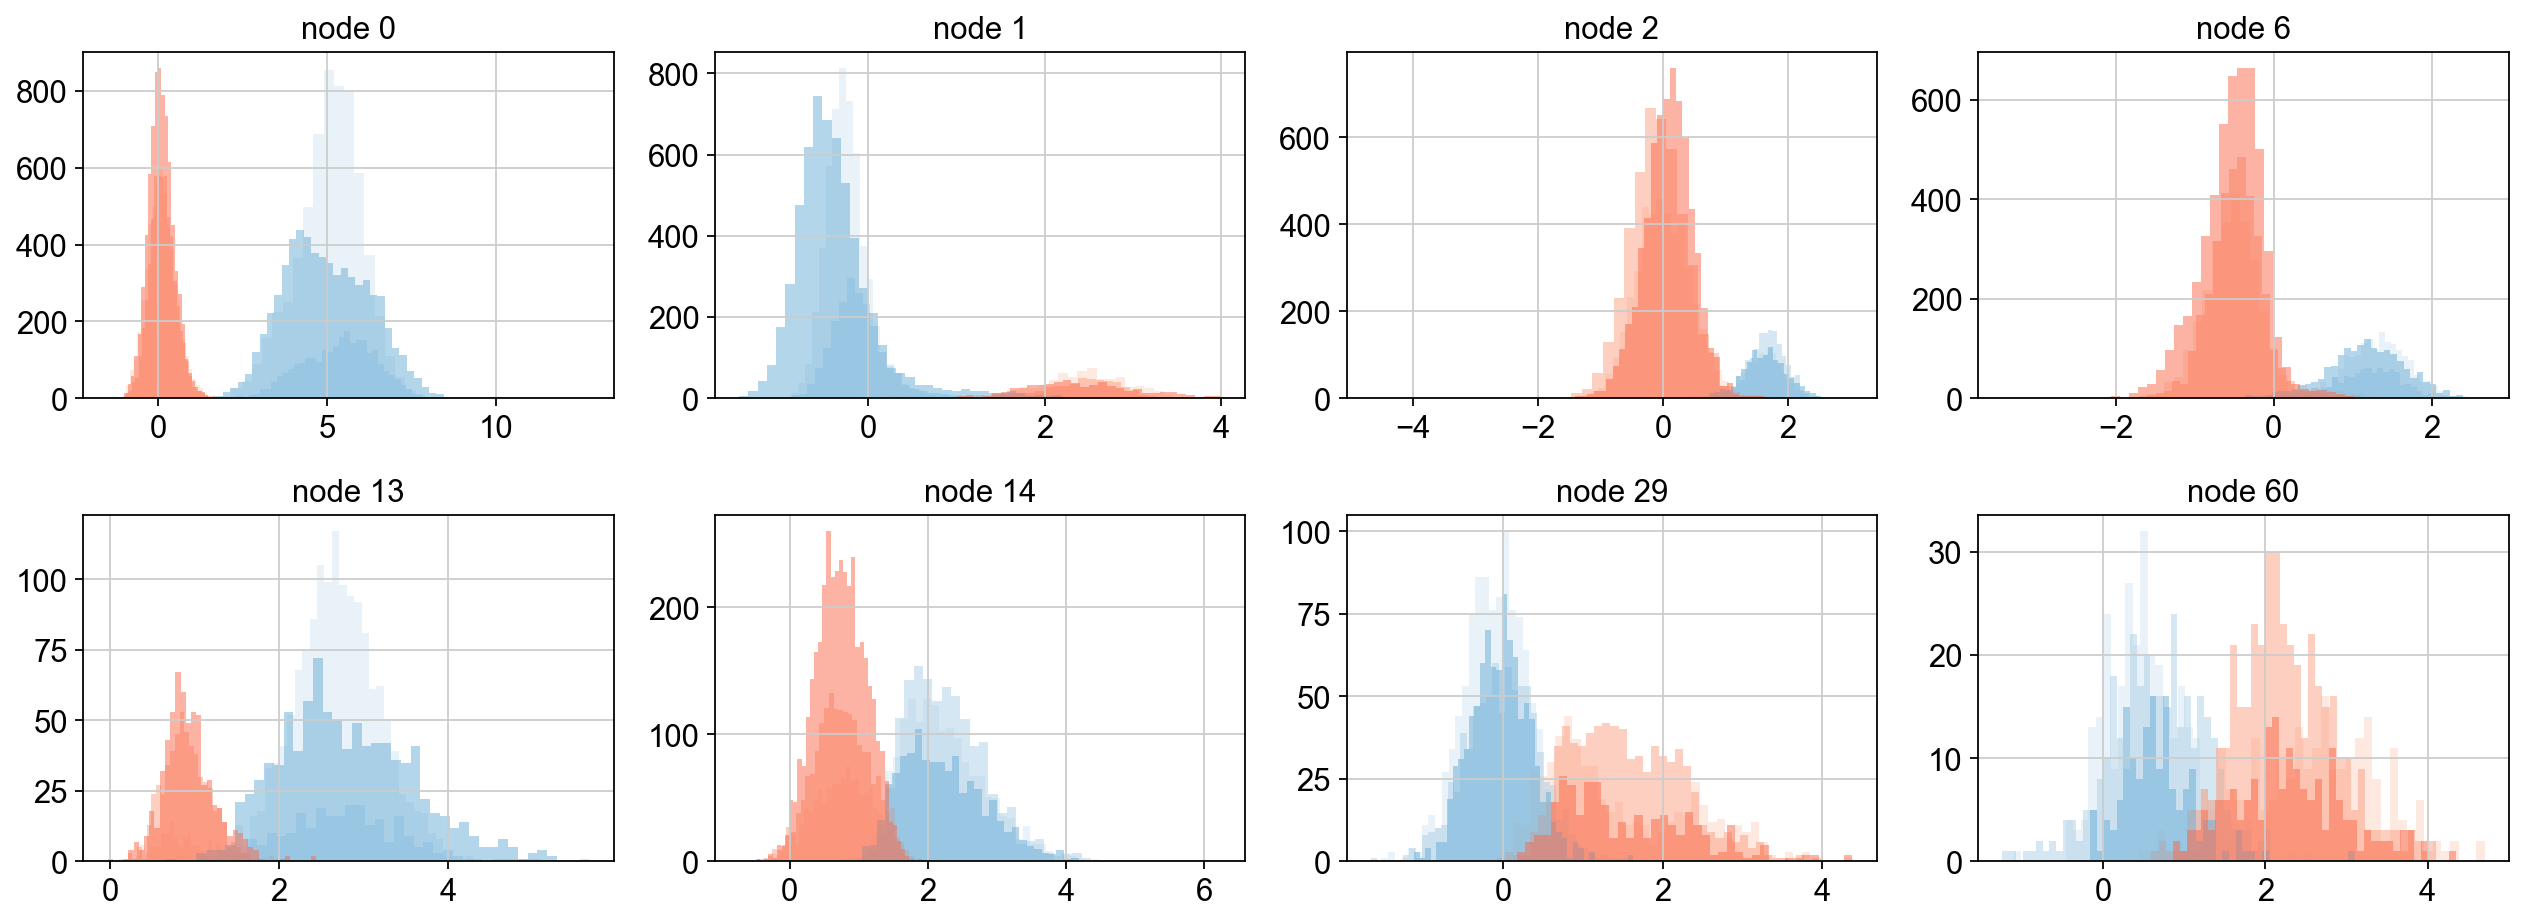

In [62]:
tree_label = pd.DataFrame(adata.obsm['treelabel'], index=adata.obs_names, columns=treelabel.columns)
# embedding = pd.read_csv('./output/mosaic celltype/3tem_test+/0/pseudo_marker.csv',index_col=0) 
# adata.obsm['X_pca_lda'] = embedding.values
nbatch = 6
import matplotlib.pyplot as plt
import numpy as np
blue_colors = [plt.cm.Blues((x+1)/nbatch) for x in range(nbatch)]  # 浅蓝到深蓝
red_colors =[plt.cm.Reds((x+1)/nbatch) for x in range(nbatch)]    # 浅红到深红

fig, axes = plt.subplots(2,4, figsize=(16, 6))
for i in range(tree_label.shape[1]):#
    node = tree_label.columns[i]
    subdata = adata[tree_label[node]!=0]
    batches = sorted(subdata.obs['batch'].unique())  
    # if i != 1:
    #     continue
    
    for batch_idx, batch in enumerate(batches):
        batch_data = subdata[subdata.obs['batch'] == batch]
        # if batch not in ['P8']:
        #     continue
        
        
        mask_neg = (tree_label[node][batch_data.obs.index] == -1)
        axes[int(i/4), int(i%4)].hist(
            batch_data.obsm['embedding'][mask_neg, i],
            bins=40, alpha=0.5,
            color=blue_colors[batch_idx],
            # label=f'{batch} (label=-1)' if batch_idx == 0 else ""
        )
        
        
        mask_pos = (tree_label[node][batch_data.obs.index] == 1)
        axes[int(i/4), int(i%4)].hist(
            batch_data.obsm['embedding'][mask_pos, i],
            bins=40, alpha=0.5,
            color=red_colors[batch_idx],
            # label=f'{batch} (label=1)' if batch_idx == 0 else ""
        )
    axes[int(i/4), int(i%4)].set_title('node '+node)
    # axes[int(i/4), int(i%4)].legend()

plt.tight_layout()
plt.show() 